# Photo Quality Classifier — SVM (multiple kernels) vs XGBoost

Dataset: `features.npz` (829-d feature vectors) + `manifest.csv` (filepath/label trace).
72 good (label 1) / 233 bad (label 0) — imbalanced, so every model below uses
class-weighting/scale_pos_weight rather than plain accuracy as the target metric.
Each classifier gets its own cell; the last cell overlays every ROC curve for comparison.

In [20]:
!pip install numpy pandas matplotlib scikit-learn xgboost

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import roc_curve, roc_auc_score, classification_report, confusion_matrix

from xgboost import XGBClassifier

RANDOM_STATE = 42

## Load data

In [22]:
import numpy as np
import pandas as pd

data = np.load("/workspace/P/dataset/img_vit_dataset.npz")

# Use 'embeddings' key (or fallback if you saved it under another name)
X = data["embeddings"]
y = data["labels"].astype(int)

manifest = pd.read_csv("/workspace/P/dataset/dataset_manifest.csv")

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Class balance -> good (1): {y.sum()}  bad (0): {len(y) - y.sum()}")

X shape: (305, 512)
y shape: (305,)
Class balance -> good (1): 72  bad (0): 233


## Train/test split + scaling

Stratified split so the ~24% positive rate is preserved in both sets.
Scaler is fit on the train split only and reused on test -- never fit on test data,
since your feature blocks (Laplacian variance, clip %, CLS token, blendshapes) are
on wildly different scales and every model here is scale-sensitive.

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train: {X_train.shape[0]} samples ({y_train.sum()} good / {len(y_train) - y_train.sum()} bad)")
print(f"Test:  {X_test.shape[0]} samples ({y_test.sum()} good / {len(y_test) - y_test.sum()} bad)")

# Collected here so the final cell can plot every model's ROC curve together.
results = {}

def evaluate(name, model, X_te, y_te):
    y_pred = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1]

    fpr, tpr, _ = roc_curve(y_te, y_proba)
    auc = roc_auc_score(y_te, y_proba)
    results[name] = {"fpr": fpr, "tpr": tpr, "auc": auc}

    print(f"=== {name} ===")
    print(f"ROC AUC: {auc:.3f}\n")
    print(classification_report(y_te, y_pred, target_names=["bad", "good"]))
    print("Confusion matrix (rows=actual, cols=predicted):")
    print(confusion_matrix(y_te, y_pred))

    plt.figure(figsize=(5, 5))
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")
    plt.plot([0, 1], [0, 1], "k--", alpha=0.4)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve — {name}")
    plt.legend()
    plt.show()

Train: 244 samples (58 good / 186 bad)
Test:  61 samples (14 good / 47 bad)


## SVM — Linear kernel

Try this first. DINOv3 CLS-token features are explicitly evaluated for linear
separability during DINO's own benchmarking, so linear is a fair baseline, not
a weak one -- and with 829 dims on only ~244 training samples, linear is far
less prone to overfitting than RBF/poly at this sample size.
`class_weight="balanced"` compensates for the 72/233 imbalance.

=== SVM (linear) ===
ROC AUC: 0.571

              precision    recall  f1-score   support

         bad       0.78      0.74      0.76        47
        good       0.25      0.29      0.27        14

    accuracy                           0.64        61
   macro avg       0.51      0.52      0.51        61
weighted avg       0.66      0.64      0.65        61

Confusion matrix (rows=actual, cols=predicted):
[[35 12]
 [10  4]]


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


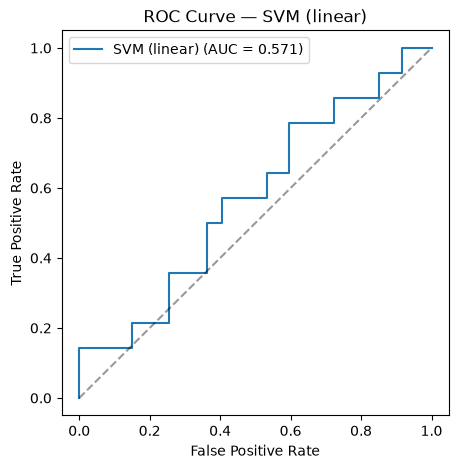

In [24]:
svm_linear = SVC(kernel="linear", probability=True, class_weight="balanced", random_state=RANDOM_STATE)
svm_linear.fit(X_train_scaled, y_train)
evaluate("SVM (linear)", svm_linear, X_test_scaled, y_test)

## SVM — RBF kernel

The default go-to kernel for non-linear boundaries. Worth comparing against linear
directly -- if RBF doesn't clearly beat linear here, prefer linear anyway (simpler,
less prone to overfitting at this dataset size).

=== SVM (RBF) ===
ROC AUC: 0.526



/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


              precision    recall  f1-score   support

         bad       0.76      0.72      0.74        47
        good       0.19      0.21      0.20        14

    accuracy                           0.61        61
   macro avg       0.47      0.47      0.47        61
weighted avg       0.63      0.61      0.62        61

Confusion matrix (rows=actual, cols=predicted):
[[34 13]
 [11  3]]


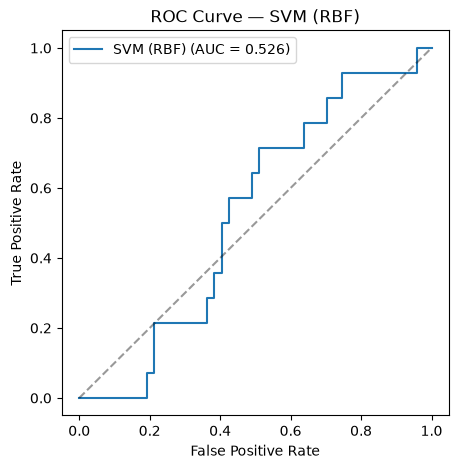

In [25]:
svm_rbf = SVC(kernel="rbf", probability=True, class_weight="balanced", random_state=RANDOM_STATE)
svm_rbf.fit(X_train_scaled, y_train)
evaluate("SVM (RBF)", svm_rbf, X_test_scaled, y_test)

## SVM — Polynomial kernel (degree 3)

Captures interaction effects between features (e.g. blur x lighting jointly, not
just each alone). More prone to overfitting than RBF at this sample size --
watch the train vs test gap.

/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


=== SVM (poly, degree=3) ===
ROC AUC: 0.527

              precision    recall  f1-score   support

         bad       0.79      0.96      0.87        47
        good       0.50      0.14      0.22        14

    accuracy                           0.77        61
   macro avg       0.64      0.55      0.54        61
weighted avg       0.72      0.77      0.72        61

Confusion matrix (rows=actual, cols=predicted):
[[45  2]
 [12  2]]


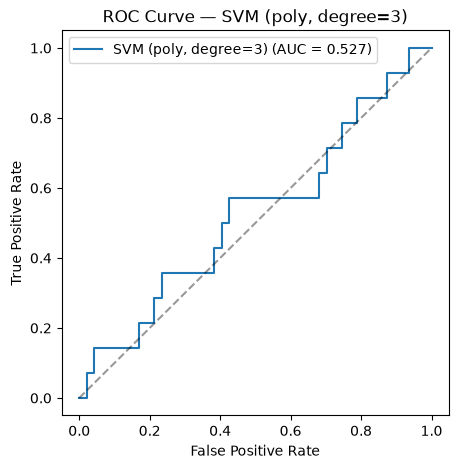

In [26]:
svm_poly = SVC(kernel="poly", degree=3, probability=True, class_weight="balanced", random_state=RANDOM_STATE)
svm_poly.fit(X_train_scaled, y_train)
evaluate("SVM (poly, degree=3)", svm_poly, X_test_scaled, y_test)

## SVM — Sigmoid kernel

Included for completeness -- behaves similarly to a shallow neural net's output
layer. Rarely the best choice for tabular/embedding features like this, but cheap
to check.

/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


=== SVM (sigmoid) ===
ROC AUC: 0.547

              precision    recall  f1-score   support

         bad       0.77      0.49      0.60        47
        good       0.23      0.50      0.31        14

    accuracy                           0.49        61
   macro avg       0.50      0.49      0.45        61
weighted avg       0.64      0.49      0.53        61

Confusion matrix (rows=actual, cols=predicted):
[[23 24]
 [ 7  7]]


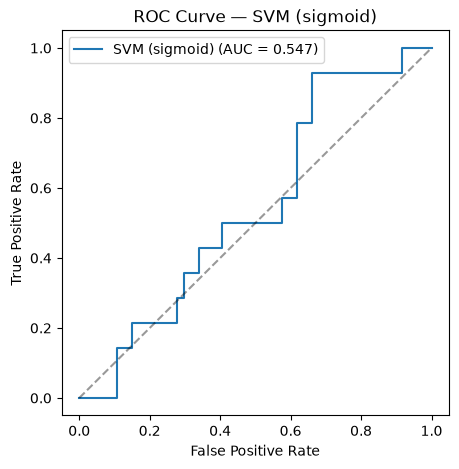

In [27]:
svm_sigmoid = SVC(kernel="sigmoid", probability=True, class_weight="balanced", random_state=RANDOM_STATE)
svm_sigmoid.fit(X_train_scaled, y_train)
evaluate("SVM (sigmoid)", svm_sigmoid, X_test_scaled, y_test)

## XGBoost

Tree-based, handles the heterogeneous feature scales natively (no StandardScaler
needed, though reusing the scaled data here doesn't hurt trees). `scale_pos_weight`
is XGBoost's equivalent of `class_weight="balanced"` -- ratio of negative to
positive samples in the training set.

=== XGBoost ===
ROC AUC: 0.454

              precision    recall  f1-score   support

         bad       0.75      0.83      0.79        47
        good       0.11      0.07      0.09        14

    accuracy                           0.66        61
   macro avg       0.43      0.45      0.44        61
weighted avg       0.60      0.66      0.63        61

Confusion matrix (rows=actual, cols=predicted):
[[39  8]
 [13  1]]


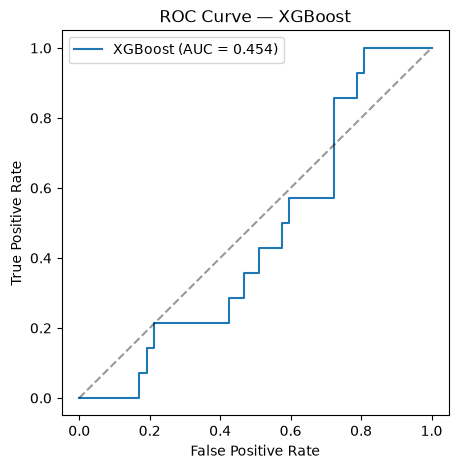

In [28]:
scale_pos_weight = (len(y_train) - y_train.sum()) / y_train.sum()

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    random_state=RANDOM_STATE,
)
xgb_model.fit(X_train_scaled, y_train)
evaluate("XGBoost", xgb_model, X_test_scaled, y_test)

## Combined comparison

All ROC curves on one plot, plus a sorted AUC table. With only ~61 test samples,
treat AUC differences under ~0.05 as noise rather than a real ranking -- re-run
with a different `random_state` in the split above to sanity-check stability.

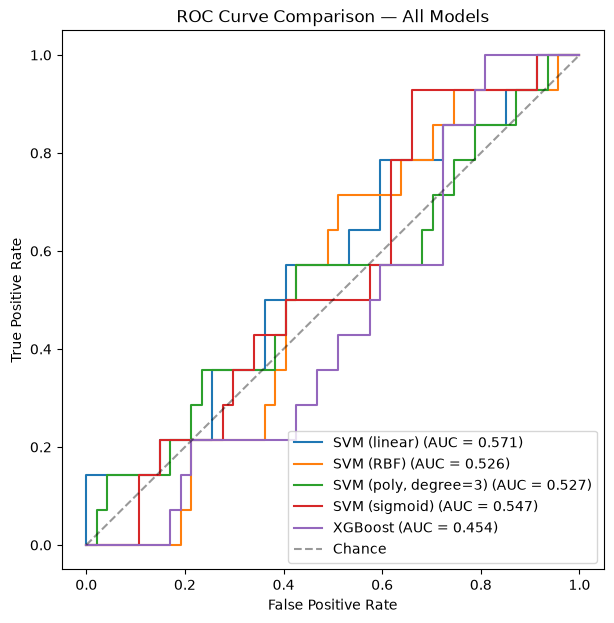

,model,roc_auc
0,SVM (linear),0.571429
1,SVM (sigmoid),0.547112
2,"SVM (poly, degree=3)",0.527356
3,SVM (RBF),0.525836
4,XGBoost,0.454407


In [29]:
plt.figure(figsize=(7, 7))
for name, res in results.items():
    plt.plot(res["fpr"], res["tpr"], label=f"{name} (AUC = {res['auc']:.3f})")
plt.plot([0, 1], [0, 1], "k--", alpha=0.4, label="Chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison — All Models")
plt.legend(loc="lower right")
plt.show()

summary = pd.DataFrame(
    [(name, res["auc"]) for name, res in results.items()],
    columns=["model", "roc_auc"],
).sort_values("roc_auc", ascending=False).reset_index(drop=True)
summary